In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from keras.datasets import fashion_mnist
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import joblib
from sklearn.ensemble import RandomForestClassifier

In [12]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [13]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [14]:
nsamples, nx, ny = x_train.shape
x_train2 = x_train.reshape((nsamples, nx * ny))

In [15]:
nsamples, nx, ny = x_test.shape
x_test2 = x_test.reshape((nsamples, nx * ny))

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

In [18]:
estimator = [('LR',LogisticRegression(max_iter=200)),('KNN',KNeighborsClassifier(n_neighbors=3))]
vot_soft = VotingClassifier(estimators=estimator,voting = 'hard',n_jobs=-1)
vot_soft.fit(x_train2,y_train)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('LR', ...), ('KNN', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [19]:
y_pred_VC = vot_soft.predict(x_test2)
y_pred_VC

array([9, 2, 1, ..., 6, 1, 5], shape=(10000,), dtype=uint8)

In [20]:
print(accuracy_score(y_pred_VC,y_test)*100)

85.53


In [21]:
print(precision_score(y_pred_VC,y_test,average='macro')*100)

85.53


In [22]:
print(recall_score(y_pred_VC,y_test,average='macro')*100)

86.31787666573815


In [23]:
print(f1_score(y_pred_VC,y_test,average='macro')*100)

85.1692432927081


In [29]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import six
import sys
sys.modules['sklearn.externals.six'] = six
from mlxtend.classifier import StackingClassifier

In [31]:
knn = KNeighborsClassifier(n_neighbors=3)
NB = GaussianNB()

model_KNC = knn.fit(x_train2,y_train)
pred_KNC = model_KNC.predict(x_test2)

print('Accuracy score of KNeighbors Classifier :',(accuracy_score(y_test,pred_KNC))*100)

Accuracy score of KNeighbors Classifier : 85.41


In [32]:
NB = GaussianNB()

model_NB = NB.fit(x_train2, y_train)
pred_NB = model_NB.predict(x_test2)

print('Accuracy score of Naive Bayes Classifier :', (accuracy_score(y_test, pred_NB)) * 100)

Accuracy score of Naive Bayes Classifier : 58.56


In [36]:
lr = LogisticRegression(solver='saga', max_iter=200)

clf_stack = StackingClassifier(
    classifiers=[knn, NB],
    meta_classifier=lr,
    use_probas=True,
    use_features_in_secondary=True
)

model_stack = clf_stack.fit(x_train2, y_train)

pred_stack = model_stack.predict(x_test2)

print('Accuracy score of Stacked model :', (accuracy_score(y_test, pred_stack)) * 100)

c:\Users\vasum\Desktop\Diya\SML\Supervised-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy score of Stacked model : 86.86


In [38]:
print(precision_score(pred_stack,y_test,average='macro')*100)
print(recall_score(pred_stack,y_test,average='macro')*100)
print(f1_score(pred_stack,y_test,average='macro')*100)

86.86
87.00905281056878
86.9062381522705


In [39]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=50,learning_rate=2, random_state=0)
ada.fit(x_train2,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [40]:
y_pred_ada = ada.predict(x_test2)
y_pred_ada

array([9, 2, 1, ..., 8, 3, 8], shape=(10000,), dtype=uint8)

In [41]:
print(accuracy_score(y_pred_ada,y_test)*100)
print(precision_score(y_pred_ada,y_test,average='macro')*100)
print(recall_score(y_pred_ada,y_test,average='macro')*100)
print(f1_score(y_pred_ada,y_test,average='macro')*100)

46.47
46.47
45.95670221512839
40.4604170601422


Predicted: [3]
Actual: 3


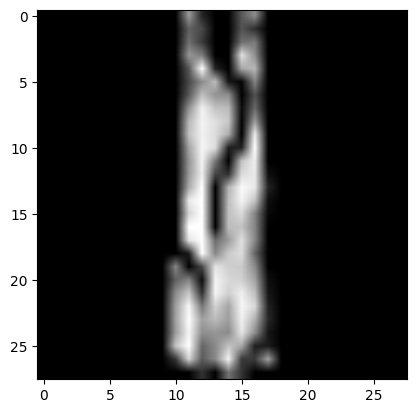

In [44]:
pre = x_test[32].reshape(1,-1)
y_pred_1 = vot_soft.predict(pre)

p = plt.subplot(1,1,1)
p.imshow(x_test[32],cmap=plt.cm.gray,interpolation='bilinear')

print('Predicted:',y_pred_1)
print('Actual:',y_test[32])

Predicted: [1]
Actual: 1


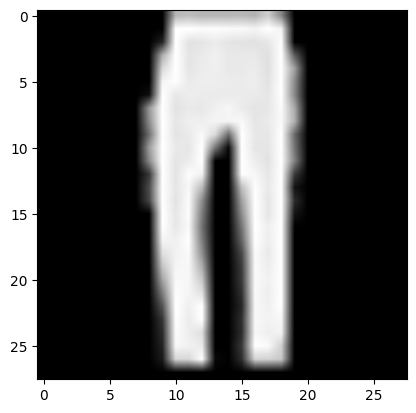

In [45]:
pre = x_test[64].reshape(1,-1)
y_pred_2 = model_stack.predict(pre)

p = plt.subplot(1,1,1)
p.imshow(x_test[64],cmap=plt.cm.gray,interpolation='bilinear')

print('Predicted:',y_pred_2)
print('Actual:',y_test[64])

Predicted: [2]
Actual: 2


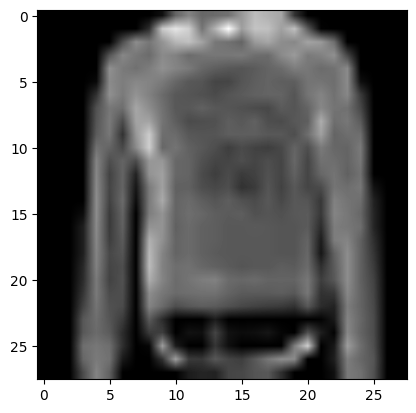

In [46]:
pre = x_test[16].reshape(1,-1)
y_pred_3 = ada.predict(pre)

p = plt.subplot(1,1,1)
p.imshow(x_test[16],cmap=plt.cm.gray,interpolation='bilinear')

print('Predicted:',y_pred_3)
print('Actual:',y_test[16])